In [8]:
# Import required packages

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from tqdm import tqdm


# Packages related to NN Question
from dataclasses import dataclass
from typing import Tuple, Optional, Callable
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 1. Naive Bayes


In [11]:
# This is the helper function to load the dataset. PLEASE DO NOT CHANGE THIS.

# --- Dataset ---

rows = [
{"ID":1, "Age":"<=30", "Income":"Average", "Student":"No", "Credit":"Fair", "Buy":"No"},
{"ID":2, "Age":"<=30", "Income":"High", "Student":"Yes", "Credit":"Good", "Buy":"No"},
{"ID":3, "Age":"30-40", "Income":"High", "Student":"No", "Credit":"Fair", "Buy":"Yes"},
{"ID":4, "Age":">40", "Income":"Low", "Student":"No", "Credit":"Fair", "Buy":"Yes"},
{"ID":5, "Age":">40", "Income":"Low", "Student":"Yes", "Credit":"Good", "Buy":"Yes"},
{"ID":6, "Age":">40", "Income":"Average", "Student":"Yes", "Credit":"Good", "Buy":"No"},
{"ID":7, "Age":"30-40", "Income":"Low", "Student":"Yes", "Credit":"Good", "Buy":"Yes"},
{"ID":8, "Age":"<=30", "Income":"Average", "Student":"No", "Credit":"Fair", "Buy":"No"},
{"ID":9, "Age":"<=30", "Income":"Low", "Student":"No", "Credit":"Fair", "Buy":"Yes"},
{"ID":10,"Age":">40", "Income":"Average", "Student":"Yes", "Credit":"Fair", "Buy":"Yes"},
{"ID":11,"Age":"<=30", "Income":"Average", "Student":"Yes", "Credit":"Good", "Buy":"Yes"},
{"ID":12,"Age":"30-40", "Income":"High", "Student":"No", "Credit":"Good", "Buy":"Yes"},
{"ID":13,"Age":"30-40", "Income":"Average", "Student":"Yes", "Credit":"Fair", "Buy":"Yes"},
{"ID":14,"Age":">40", "Income":"Average", "Student":"No", "Credit":"Good", "Buy":"No"},
]

# We need to convert it to pandas dataframe format.
df = pd.DataFrame(rows)

In [13]:
# Please IMPLEMENT your code for the below function

FEATURE_CARD = df[['Age','Income','Student','Credit']].nunique().to_dict()

def conditional_prob(df_class, feature, value, alpha=0.0):
    """
    Return P(feature = value | class) with Laplace smoothing.
    df_class: subset of df for a class (e.g., df[df['Buy']=='Yes'])
    feature : column name
    value   : feature value to query
    alpha   : Laplace smoothing parameter (alpha=0 means no smoothing)
    """
    K = FEATURE_CARD[feature]
    n = len(df_class)
    count = (df_class[feature] == value).sum()
    return (count + alpha) / (n + alpha * K)

# class splits and priors
df_yes = df[df['Buy']=='Yes']
df_no  = df[df['Buy']=='No']
priors = {'Yes': len(df_yes)/len(df), 'No': len(df_no)/len(df)}

# --- 1a ---
p1a = conditional_prob(df_yes, 'Income', 'High', alpha=0)  # no smoothing
print(f"1a) P(Income=High | Buy=Yes) = {p1a:.3f}")  # -> 0.222

# --- 1b (Laplace alpha=1) ---
p1b = conditional_prob(df_no, 'Age', '30-40', alpha=1)
print(f"1b) P(30<Age<40 | Buy=No, α=1) = {p1b:.3f}")  # -> 0.125

# --- 1c (NB product under Buy=Yes, no smoothing unless told) ---
features_1c = [('Age','>40'), ('Income','High'), ('Student','No'), ('Credit','Good')]
p1c = np.prod([conditional_prob(df_yes, f, v, alpha=0) for f,v in features_1c])
print(f"1c) P(Age>40,Income=High,Student=No,Credit=Good | Buy=Yes) = {p1c:.3f}")  # -> ~0.015

# helper to compute Naive Bayes posteriors for a feature dict
def nb_posteriors(x, alpha=0.0):
    post = {}
    for c, df_c in [('Yes', df_yes), ('No', df_no)]:
        like = 1.0
        for f, v in x.items():
            like *= conditional_prob(df_c, f, v, alpha=alpha)
        post[c] = priors[c] * like
    # normalize
    total = sum(post.values())
    return {c: post[c]/total for c in post}

# --- 1d ---
x_new = {'Age':'<=30', 'Income':'Average', 'Student':'Yes', 'Credit':'Fair'}

post0 = nb_posteriors(x_new, alpha=0)   # without smoothing
post1 = nb_posteriors(x_new, alpha=1)   # with smoothing

print(f"1d) Posteriors without smoothing:  P(No|x)={post0['No']:.3f}  vs  P(Yes|x)={post0['Yes']:.3f}")
print(f"    Posteriors with α=1:           P(No|x)={post1['No']:.3f}  vs  P(Yes|x)={post1['Yes']:.3f}")

pred_no_smooth = 'No' if post0['No'] > post0['Yes'] else 'Yes'
pred_smooth    = 'No' if post1['No'] > post1['Yes'] else 'Yes'
print(f"    Prediction (no smoothing): {pred_no_smooth}")
print(f"    Prediction (α=1):          {pred_smooth}")


1a) P(Income=High | Buy=Yes) = 0.222
1b) P(30<Age<40 | Buy=No, α=1) = 0.125
1c) P(Age>40,Income=High,Student=No,Credit=Good | Buy=Yes) = 0.015
1d) Posteriors without smoothing:  P(No|x)=0.651  vs  P(Yes|x)=0.349
    Posteriors with α=1:           P(No|x)=0.563  vs  P(Yes|x)=0.437
    Prediction (no smoothing): No
    Prediction (α=1):          No


In [15]:
# Your remaining code here
import pandas as pd
import numpy as np

# Dataset
rows = [
    {"ID":1, "Age":"<=30", "Income":"Average", "Student":"No", "Credit":"Fair", "Buy":"No"},
    {"ID":2, "Age":"<=30", "Income":"High", "Student":"Yes", "Credit":"Good", "Buy":"No"},
    {"ID":3, "Age":"30-40", "Income":"High", "Student":"No", "Credit":"Fair", "Buy":"Yes"},
    {"ID":4, "Age":">40", "Income":"Low", "Student":"No", "Credit":"Fair", "Buy":"Yes"},
    {"ID":5, "Age":">40", "Income":"Low", "Student":"Yes", "Credit":"Good", "Buy":"Yes"},
    {"ID":6, "Age":">40", "Income":"Average", "Student":"Yes", "Credit":"Good", "Buy":"No"},
    {"ID":7, "Age":"30-40", "Income":"Low", "Student":"Yes", "Credit":"Good", "Buy":"Yes"},
    {"ID":8, "Age":"<=30", "Income":"Average", "Student":"No", "Credit":"Fair", "Buy":"No"},
    {"ID":9, "Age":"<=30", "Income":"Low", "Student":"No", "Credit":"Fair", "Buy":"Yes"},
    {"ID":10,"Age":">40", "Income":"Average", "Student":"Yes", "Credit":"Fair", "Buy":"Yes"},
    {"ID":11,"Age":"<=30", "Income":"Average", "Student":"Yes", "Credit":"Good", "Buy":"Yes"},
    {"ID":12,"Age":"30-40", "Income":"High", "Student":"No", "Credit":"Good", "Buy":"Yes"},
    {"ID":13,"Age":"30-40", "Income":"Average", "Student":"Yes", "Credit":"Fair", "Buy":"Yes"},
    {"ID":14,"Age":">40", "Income":"Average", "Student":"No", "Credit":"Good", "Buy":"No"},
]

df = pd.DataFrame(rows)

# Define possible values for each feature for Laplace smoothing
feature_values = {
    'Age': ['<=30', '30-40', '>40'],
    'Income': ['Low', 'Average', 'High'],
    'Student': ['Yes', 'No'],
    'Credit': ['Fair', 'Good']
}

def conditional_prob(df_class, feature, value, alpha):
    """
    Return P(feature = value | class)
    df_class: subset of dataframe for the class label
    feature: column name
    value: feature value to query
    alpha: laplace smoothing parameter
    """
    count_value = len(df_class[df_class[feature] == value])
    total_count = len(df_class)
    num_categories = len(feature_values[feature])
    
    # Apply Laplace smoothing
    probability = (count_value + alpha) / (total_count + alpha * num_categories)
    return probability

# Question 1a: P(Income = High | Buy House = Yes)
df_yes = df[df['Buy'] == 'Yes']
p_income_high_yes = conditional_prob(df_yes, 'Income', 'High', alpha=0)  # No smoothing
print(f"1a. P(Income = High | Buy House = Yes) = {p_income_high_yes:.3f}")

# Question 1b: P(30 < Age < 40 | Buy House = No) with Laplace smoothing (alpha=1)
df_no = df[df['Buy'] == 'No']
p_age_30_40_no = conditional_prob(df_no, 'Age', '30-40', alpha=1)  # With Laplace smoothing
print(f"1b. P(30 < Age < 40 | Buy House = No) = {p_age_30_40_no:.3f}")

# Question 1c: Joint probability P(Age>40, Income=High, Student=No, Credit=Good | Buy=Yes)
p_age_yes = conditional_prob(df_yes, 'Age', '>40', alpha=0)
p_income_yes = conditional_prob(df_yes, 'Income', 'High', alpha=0)
p_student_yes = conditional_prob(df_yes, 'Student', 'No', alpha=0)
p_credit_yes = conditional_prob(df_yes, 'Credit', 'Good', alpha=0)

joint_prob = p_age_yes * p_income_yes * p_student_yes * p_credit_yes
print(f"1c. Joint probability = {joint_prob:.3f}")

# Question 1d: Predict for new person
# Priors
p_yes = len(df_yes) / len(df)
p_no = len(df_no) / len(df)

# For Buy = Yes
p_age_yes = conditional_prob(df_yes, 'Age', '<=30', alpha=0)
p_income_yes = conditional_prob(df_yes, 'Income', 'Average', alpha=0)
p_student_yes = conditional_prob(df_yes, 'Student', 'Yes', alpha=0)
p_credit_yes = conditional_prob(df_yes, 'Credit', 'Fair', alpha=0)

posterior_yes = p_yes * p_age_yes * p_income_yes * p_student_yes * p_credit_yes

# For Buy = No
p_age_no = conditional_prob(df_no, 'Age', '<=30', alpha=0)
p_income_no = conditional_prob(df_no, 'Income', 'Average', alpha=0)
p_student_no = conditional_prob(df_no, 'Student', 'Yes', alpha=0)
p_credit_no = conditional_prob(df_no, 'Credit', 'Fair', alpha=0)

posterior_no = p_no * p_age_no * p_income_no * p_student_no * p_credit_no

print(f"\n1d. Results:")
print(f"P(Buy House = No | features) = {posterior_no:.6f}")
print(f"P(Buy House = Yes | features) = {posterior_yes:.6f}")

if posterior_no > posterior_yes:
    prediction = "No"
else:
    prediction = "Yes"

print(f"Prediction: Buy House = {prediction}")

1a. P(Income = High | Buy House = Yes) = 0.222
1b. P(30 < Age < 40 | Buy House = No) = 0.125
1c. Joint probability = 0.015

1d. Results:
P(Buy House = No | features) = 0.027429
P(Buy House = Yes | features) = 0.014697
Prediction: Buy House = No


# 2. Decision Tree


In [5]:
# This is the helper function to load the dataset. PLEASE DO NOT CHANGE THIS.

# --- Dataset ---
rows = [
    {"ID":1, "Age":"<=30",   "Income":"Average",  "Student":"No",  "Credit":"Fair",  "Buy":"No"},
    {"ID":2, "Age":"<=30",   "Income":"High",     "Student":"Yes", "Credit":"Good",  "Buy":"No"},
    {"ID":3, "Age":"30-40",  "Income":"High",     "Student":"No",  "Credit":"Fair",  "Buy":"Yes"},
    {"ID":4, "Age":">40",    "Income":"Low",      "Student":"No",  "Credit":"Fair",  "Buy":"Yes"},
    {"ID":5, "Age":">40",    "Income":"Low",      "Student":"Yes", "Credit":"Good",  "Buy":"Yes"},
    {"ID":6, "Age":">40",    "Income":"Average",  "Student":"Yes", "Credit":"Good",  "Buy":"No"},
    {"ID":7, "Age":"30-40",  "Income":"Low",      "Student":"Yes", "Credit":"Good",  "Buy":"Yes"},
    {"ID":8, "Age":"<=30",   "Income":"Average",  "Student":"No",  "Credit":"Fair",  "Buy":"No"},
    {"ID":9, "Age":"<=30",   "Income":"Low",      "Student":"No",  "Credit":"Fair",  "Buy":"Yes"},
    {"ID":10,"Age":">40",    "Income":"Average",  "Student":"Yes", "Credit":"Fair",  "Buy":"Yes"},
    {"ID":11,"Age":"<=30",   "Income":"Average",  "Student":"Yes", "Credit":"Good",  "Buy":"Yes"},
    {"ID":12,"Age":"30-40",  "Income":"High",     "Student":"No",  "Credit":"Good",  "Buy":"Yes"},
    {"ID":13,"Age":"30-40",  "Income":"Average",  "Student":"Yes", "Credit":"Fair",  "Buy":"Yes"},
    {"ID":14,"Age":">40",    "Income":"Average",  "Student":"No",  "Credit":"Good",  "Buy":"No"},
]

df = pd.DataFrame(rows)

In [6]:
# Please IMPLEMENT your code for the below function

def entropy(target_col):
    """Compute entropy of a pandas Series"""


In [7]:
# Please IMPLEMENT your code for the below function

def info_gain(df, split_attr, target='Buy'):
    """Compute information gain of splitting df by split_attr"""

In [19]:
import math
def entropy(target_col):
    """Compute entropy of a pandas Series"""
    n = len(target_col)
    counts = target_col.value_counts()
    return -sum((c/n) * math.log2(c/n) for c in counts)

# --- information gain for a split attribute ---
def info_gain(df, split_attr, target='Buy'):
    """Compute information gain of splitting df by split_attr"""
    H = entropy(df[target])
    n = len(df)
    cond_H = 0.0
    for _, group in df.groupby(split_attr):
        cond_H += (len(group)/n) * entropy(group[target])
    return H - cond_H

# 2a
H_target = entropy(df['Buy'])
print(f"2a) Entropy of target = {H_target:.3f}")   # 0.940

# 2b
IG_student = info_gain(df, 'Student', target='Buy')
print(f"2b) Information gain for split on 'Student' = {IG_student:.3f}")  # 0.016

# 2c verify by actually building a tiny ID3 tree
def id3(df, features, target='Buy'):
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]
    if not features:
        return df[target].mode()[0]
    gains = {f: info_gain(df, f, target) for f in features}
    best = max(gains, key=gains.get)
    tree = {best: {}}
    for v, sub in df.groupby(best):
        tree[best][v] = id3(sub, [f for f in features if f != best], target)
    return tree

def predict(tree, x):
    if not isinstance(tree, dict):
        return tree
    (feat, branches), = tree.items()
    v = x.get(feat)
    return predict(branches[v], x)

tree = id3(df, ['Age','Income','Student','Credit'])
preds_30_40 = [predict(tree, row.to_dict()) for _, row in df[df['Age']=='30-40'].iterrows()]
all_yes = all(p == 'Yes' for p in preds_30_40)
print("2c) This tree predicts Buy=Yes for all records with Age in (30,40):", "True" if all_yes else "False")

2a) Entropy of target = 0.940
2b) Information gain for split on 'Student' = 0.016
2c) This tree predicts Buy=Yes for all records with Age in (30,40): True


# 3. Netflix Recommender System

In [23]:
# This is the helper function to load the dataset. PLEASE DO NOT CHANGE THIS.

def load_ratings_data_pandas(data_dir="ml-latest-small/"):
    """Load data using pandas dataframes."""
    data_dir = Path(data_dir)
    assert data_dir.exists(), f"{data_dir} does not exist"

    return pd.read_csv(data_dir / 'ratings.csv',sep=',')


def load_movies_data_pandas(data_dir="ml-latest-small/"):
    """Load data using pandas dataframes."""
    data_dir = Path(data_dir)
    assert data_dir.exists(), f"{data_dir} does not exist"
    return pd.read_csv(data_dir / 'movies.csv')

def filter_data(ratings_data: pd.DataFrame, movies_data: pd.DataFrame):
    """Filter data. Too little ratings prevent effective use of matrix completion."""
    ratings_data = ratings_data.pivot(
        index='userId',
        columns='movieId',
        values='rating'
    ).fillna(0)

    keep_movie = (ratings_data != 0).sum(axis=0) > 100
    ratings_data = ratings_data.loc[:, keep_movie]

    # Filter movies_data by movieId (columns of ratings_data after filtering)
    movies_data = movies_data[movies_data['movieId'].isin(ratings_data.columns)]

    keep_user = (ratings_data != 0).sum(axis=1) >= 5
    ratings_data = ratings_data.loc[keep_user, :]

    return ratings_data, movies_data

def print_data_summary(ratings: pd.DataFrame):
    n_users = ratings.shape[0]
    n_movies = ratings.shape[1]
    n_ratings = (ratings != 0).sum().sum()
    density = n_ratings / (n_users * n_movies)

    print(f"Dataset Summary")
    print(f"----------------")
    print(f"Users: {n_users}")
    print(f"Movies: {n_movies}")
    print(f"Total Ratings: {n_ratings}")
    print(f"Data Density: {density:.4f} (fraction of observed ratings)")

def load_data_pandas(data_dir="ml-latest-small/", print_summary=False):
    """Load data in pandas format."""
    ratings, movies = filter_data(
        load_ratings_data_pandas(data_dir=data_dir),
        load_movies_data_pandas(data_dir=data_dir)
    )
    if print_summary:
        print_data_summary(ratings)
    return ratings, movies


def load_data(data_dir="ml-latest-small/", print_summary=False):
    """Load data in numpy format."""
    ratings, movies = load_data_pandas(data_dir=data_dir, print_summary=print_summary)
    return ratings.to_numpy(), movies.to_numpy()

In [25]:
# Please IMPLEMENT your code for the below function and DONT forget to provide correct n_features (r),  t_max and lambda.
# You can use the same function for Question 3b to run the matrix completion algorithm with different lambda values.
import numpy as np

def matrix_completion(D, n_features, n_movies, n_users, t_max, lambd):
    """
    Block coordinate descent:
    For each movie k:  (Y^T O^k Y + λI) x_k = Y^T O^k d^k
    For each user  i:  (X^T O^i X + λI) y_i = X^T O^i d_i
    D shape: (n_users, n_movies)
    """
    O = (D != 0).astype(np.float64)
    I = np.eye(n_features, dtype=np.float64)

    # Reproducible init
    rng = np.random.RandomState(0)
    X = rng.normal(scale=0.1, size=(n_movies, n_features))  # movie factors
    Y = rng.normal(scale=0.1, size=(n_users, n_features))   # user factors

    for _ in range(t_max):
        # Update X (movie rows)
        for k in range(n_movies):
            w = O[:, k]  # which users rated movie k
            if w.sum() == 0:
                X[k, :] = 0.0
                continue
            A = Y.T @ (Y * w[:, None]) + lambd * I      # r x r
            b = Y.T @ (D[:, k] * w)                     # r
            X[k, :] = np.linalg.solve(A, b)

        # Update Y (user rows)
        for i in range(n_users):
            w = O[i, :]  # which movies user i rated
            if w.sum() == 0:
                Y[i, :] = 0.0
                continue
            A = X.T @ (X * w[:, None]) + lambd * I      # r x r
            b = X.T @ (D[i, :] * w)                     # r
            Y[i, :] = np.linalg.solve(A, b)

    return X, Y

# ----------------- Driver for Q3a -----------------
# 1) Load and filter
ratings_pd, movies_pd = load_data_pandas(data_dir=r"C:\Users\Yijie\datasets\ml-latest-small", print_summary=True)
D = ratings_pd.to_numpy(dtype=float)
n_users, n_movies = D.shape

# 2) Hyperparameters per the question
r = 20
t_max = 100
lambd = 0.1

# 3) Train
X, Y = matrix_completion(D, n_features=r, n_movies=n_movies, n_users=n_users,
                         t_max=t_max, lambd=lambd)

# 4) Mean squared approximation error on observed entries
O = (D != 0).astype(float)
R_hat = Y @ X.T
mse = ((O * (D - R_hat))**2).sum() / O.sum()
print(f"Mean squared error after {t_max} iterations: {mse:.6f}")

# 5) Predictions for first user u=0 for the 4 requested titles
u = 0
wanted_titles = [
    "Jumanji (1995)",
    "Fight Club (1999)",
    "Matrix, The (1999)",
    "Monty Python and the Holy Grail (1975)",
]

# Map titles -> movieIds in your filtered movies table
title_to_id = dict(zip(movies_pd['title'].to_numpy(), movies_pd['movieId'].to_numpy()))
# Ratings matrix columns are movieIds (as pivot columns); build map movieId -> column index
movie_ids_in_matrix = ratings_pd.columns.to_numpy()
id_to_col = {mid: j for j, mid in enumerate(movie_ids_in_matrix)}

print("\nEstimated ratings for first user (u=0):")
abbr = {"Jumanji (1995)":"JU", "Fight Club (1999)":"FC",
        "Matrix, The (1999)":"MT",
        "Monty Python and the Holy Grail (1975)":"MP"}

for t in wanted_titles:
    mid = title_to_id.get(t, None)
    if mid is None or mid not in id_to_col:
        print(f"{t}: not in filtered matrix")
        continue
    j = id_to_col[mid]
    pred = R_hat[u, j]
    print(f"{t}: {abbr[t]} = {pred:.3f}")


Dataset Summary
----------------
Users: 556
Movies: 134
Total Ratings: 19694
Data Density: 0.2643 (fraction of observed ratings)
Mean squared error after 100 iterations: 0.093866

Estimated ratings for first user (u=0):
Jumanji (1995): JU = 3.612
Fight Club (1999): FC = 5.018
Matrix, The (1999): MT = 4.972
Monty Python and the Holy Grail (1975): MP = 5.083


In [27]:
ratings, movies = load_data(r"C:\Users\Yijie\datasets\ml-latest-small", print_summary=True)

# YOUR CODE HERE

Dataset Summary
----------------
Users: 556
Movies: 134
Total Ratings: 19694
Data Density: 0.2643 (fraction of observed ratings)


In [29]:
# Please IMPLEMENT your code for the below function to retrieve estimated ratings for the movies from the first user.
# You can use the same function for Question 3b to run the matrix completion algorithm
# with different lambda values and report the rating for the movie "Monty Python and the Holy Grail (1975)".

def get_predicted_ratings(titles, X, Y, ratings_df, movies_df, user=0):
    """
    Retrieve predicted ratings for a list of movie titles for a specified user.

    Args:
        titles (list of str): Movie titles to predict ratings for.
        X (np.ndarray): Movie feature matrix.
        Y (np.ndarray): User feature matrix.
        ratings_df (pd.DataFrame): Ratings matrix (users × movies).
        movies_df (pd.DataFrame): DataFrame with movieId and title.
        user (int, optional): User index. Defaults to 0.

    Returns:
        dict: Dictionary mapping movie titles to predicted ratings (float),
              or None if the movie is not available in the dataset.
    """
    # Your implementation starts here

# 4. PCA for Network Intrusion Detection

In [31]:
# This is the helper function for loading the kdd_balanced dataset. PLEASE DO NOT CHANGE the below code.
# This code will load the balanced kdd dataset. In the original version the number of intrusion samples are much more than normal samples.
# In this balanced version we have 100 intrusion samples, and 97,278 normal samples.

def load_kdd_data(data_dir="./datasets/kdd_balanced"):
    """
    Load the balanced dataset from Parquet format (ultra-fast loading).

    Returns:
        D_balanced: Feature matrix (numpy array)
        is_normal_balanced: Boolean labels (numpy array)
        original_indices: Original indices from full dataset (numpy array)
        df_balanced: Original dataframe subset (if available)
        metadata: Dataset metadata
    """

    data_path = Path(data_dir)

    # Check if required files exist
    required_files = ["balanced_dataset.parquet", "metadata.json"]
    missing_files = [f for f in required_files if not (data_path / f).exists()]
    if missing_files:
        raise FileNotFoundError(f"Required files not found in {data_path}: {missing_files}")

    # Load main dataset (this is very fast with Parquet)
    df_main = pd.read_parquet(data_path / "balanced_dataset.parquet")

    # Extract components
    feature_cols = [col for col in df_main.columns if col.startswith('feature_')]
    D_balanced = df_main[feature_cols].values
    is_normal_balanced = df_main['is_normal'].values
    original_indices = df_main['original_index'].values

    # Load original dataframe if available
    df_balanced = None
    if (data_path / "original_data_balanced.parquet").exists():
        df_balanced = pd.read_parquet(data_path / "original_data_balanced.parquet")

    # Load metadata
    with open(data_path / "metadata.json", 'r') as f:
        metadata = json.load(f)

    print(f"Balanced dataset loaded from {data_path} (Parquet format)")
    print(f"  Features: {D_balanced.shape}")
    print(f"  Normal: {metadata['n_normal']:,}, Intrusion: {metadata['n_intrusion']:,}")

    return D_balanced, is_normal_balanced, original_indices, df_balanced, metadata


In [35]:
# Implement your code here.

def compute_pca_from_intrusion_data(D_intrusion, r):
    """
    Compute PCA using SVD on intrusion data with rank r.

    Key insight: We train PCA on normal data, so intrusion data
    will have higher reconstruction error in this learned space.

    Returns:
        X: Principal components (learned from normal data)
        mu_intrusion: Mean vector of normal data
    """
    mu_intrusion = D_intrusion.mean(axis=0)
    C = D_intrusion - mu_intrusion
    # SVD on centered data
    U, s, Vt = np.linalg.svd(C, full_matrices=False)
    # Take top r principal axes as columns
    X = Vt[:r].T   # shape (d, r)
    return X, mu_intrusion


In [37]:
# Implement your code here.

def project_to_low_dimensional_space(D, X, mu_intrusion):
    """
    Project any data points into the low-dimensional space defined by
    intrusion-trained PCA components.
    """
    return (D - mu_intrusion) @ X    # shape (N, r)

In [39]:
# Implement your code here.

def reconstruct_from_low_dimensional(Y, X, mu_intrusion):
    """Reconstruct data points from low-dimensional coordinates."""
    return Y @ X.T + mu_intrusion    # shape (N, d)

In [41]:
# Implement your code here.

def compute_reconstruction_error(original, reconstructed):
    """Compute L2 reconstruction error."""
    diff = original - reconstructed
    return np.sqrt(np.sum(diff * diff, axis=1))   # shape (N,)

Balanced dataset loaded from datasets\kdd_balanced (Parquet format)
  Features: (97378, 118)
  Normal: 97,278, Intrusion: 100
Balanced dataset loaded from datasets\kdd_balanced (Parquet format)
  Features: (97378, 118)
  Normal: 97,278, Intrusion: 100
Explained variance ratio sum (k=2): 0.427385
[k=2] mean error normal=3.848632  intrusion=6.160177


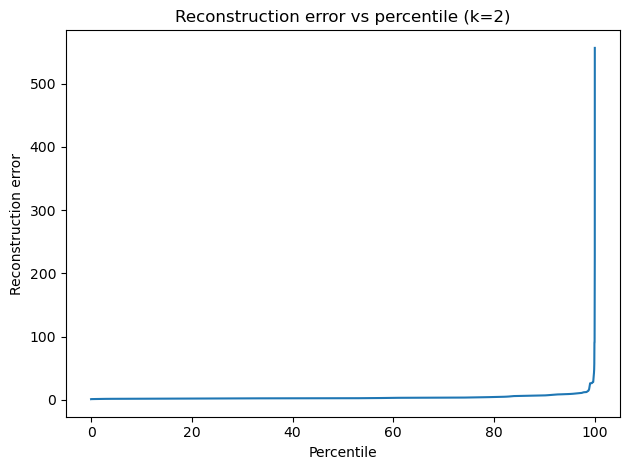

90th percentile threshold=6.954492  tp=30  fp=9708  fn=70  tn=87570
95th percentile threshold=9.225325  tp=10  fp=4859  fn=90  tn=92419
99th percentile threshold=21.934188  tp=0  fp=974  fn=100  tn=96304
Explained variance ratio sum (k=5): 0.634134
[k=5] mean error normal=3.254366  intrusion=5.888257


In [43]:
D_balanced, is_normal_balanced, original_indices, _, metadata = load_kdd_data()

# Your code here

import numpy as np
import matplotlib.pyplot as plt

# Load data
D_balanced, is_normal_balanced, original_indices, _, metadata = load_kdd_data()

# Use only NORMAL points to train PCA
is_norm = is_normal_balanced.astype(bool)
D_train = D_balanced[is_norm]

# Optional: subsample normals for speed if huge
SAMPLE_NORMALS = 50000
if D_train.shape[0] > SAMPLE_NORMALS:
    rng = np.random.default_rng(0)
    idx = rng.choice(D_train.shape[0], size=SAMPLE_NORMALS, replace=False)
    D_train_small = D_train[idx]
else:
    D_train_small = D_train

# Utility to report explained variance for any k
def explained_variance_sum(D_train_for_svd, k):
    C = D_train_for_svd - D_train_for_svd.mean(axis=0)
    U, s_all, Vt = np.linalg.svd(C, full_matrices=False)
    m = C.shape[0]
    eigvals = (s_all**2) / max(m - 1, 1)
    total_var = eigvals.sum()
    return float(eigvals[:k].sum() / total_var)

# Run for k=2 and k=5
for r in (2, 5):
    # 4a: fit PCA on normals
    X, mu = compute_pca_from_intrusion_data(D_train_small, r)

    # 4a: report explained variance sum for rank r
    ev_sum = explained_variance_sum(D_train_small, r)
    print(f"Explained variance ratio sum (k={r}): {ev_sum:.6f}")

    # 4b: project all and reconstruct
    Y_all = project_to_low_dimensional_space(D_balanced, X, mu)
    D_hat = reconstruct_from_low_dimensional(Y_all, X, mu)
    err = compute_reconstruction_error(D_balanced, D_hat)

    mean_norm = float(err[is_norm].mean())
    mean_intr = float(err[~is_norm].mean())
    print(f"[k={r}] mean error normal={mean_norm:.6f}  intrusion={mean_intr:.6f}")

    # 4c: for k=2 make percentile plot and tp/fp at 90, 95, 99
    if r == 2:
        errs_sorted = np.sort(err)
        perc = np.linspace(0, 100, len(errs_sorted), endpoint=False)
        plt.figure()
        plt.plot(perc, errs_sorted)
        plt.xlabel("Percentile")
        plt.ylabel("Reconstruction error")
        plt.title("Reconstruction error vs percentile (k=2)")
        plt.tight_layout()
        plt.show()

        y_true = ~is_norm  # True means intrusion
        for p in (90, 95, 99):
            thr = float(np.percentile(err, p))
            y_pred = err > thr
            tp = int(np.sum(y_pred & y_true))
            fp = int(np.sum(y_pred & (~y_true)))
            fn = int(np.sum((~y_pred) & y_true))
            tn = int(np.sum((~y_pred) & (~y_true)))
            print(f"{p}th percentile threshold={thr:.6f}  tp={tp}  fp={fp}  fn={fn}  tn={tn}")


# 5. K-means Initialization

In [49]:
# This is the helper function for loading the dataset. Please DO NOT CHANGE the below code.

RANDOM_SEED = 42

def load_iris_data(path=Path("datasets/iris/iris.csv")):
    df = pd.read_csv(path)
    data = df.iloc[:, :-1].values
    labels = df['target'].values
    return data, labels

def print_iris_info(data, labels):
    n_samples, n_features = data.shape
    n_classes = len(np.unique(labels))
    feature_names = ['sepal length', 'sepal width', 'petal length', 'petal width']

    print(f"Number of samples: {n_samples}")
    print(f"Number of features: {n_features}")
    print(f"Number of classes: {n_classes}")
    print(f"Feature names: {feature_names}")
    print(f"Class distribution:")
    unique, counts = np.unique(labels, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples")

In [51]:
# This is the K-means implementation from the lecture slides. PLEASE DO NOT CHANGE the code below.

def RSS(D,X,Y):
    return np.sum((D- Y@X.T)**2)

def getY(labels):
    Y = np.eye(max(labels)+1)[labels]
    return Y

def update_centroid(D,Y):
    cluster_sizes = np.diag(Y.T@Y).copy()
    cluster_sizes[cluster_sizes==0]=1
    return D.T@Y/cluster_sizes

def update_assignment(D,X):
    dist = np.sum((np.expand_dims(D,2) - X)**2,1)
    labels = np.argmin(dist,1)
    return getY(labels)

def kmeans(D,r, X_init, epsilon=0.00001, t_max=10000):
    X = X_init.copy()
    Y = update_assignment(D,X)
    rss_old = RSS(D,X,Y) +2*epsilon
    t=0

    #Looping as long as difference of objective function values is larger than epsilon
    while rss_old - RSS(D,X,Y) > epsilon and t < t_max-1:
        rss_old = RSS(D,X,Y)
        X = update_centroid(D,Y)
        Y = update_assignment(D,X)
        t+=1
    print(t,"iterations")
    return X,Y


In [53]:
# Please implement your code here.
def init_centroids_greedy_pp(D, r, l=10):
    '''
        :param r: (int) number of centroids (clusters)
        :param D: (np-array) data matrix of shape (n, d)
        :param l: (int) number of centroid candidates evaluated each step
        :return: (np-array) X the selected centroids from the dataset, shape (d, r)
    '''
    rng = np.random.default_rng(seed=RANDOM_SEED)
    n, d = D.shape

    # 1) choose first center uniformly at random
    first_idx = rng.integers(low=0, high=n)
    chosen = [first_idx]

    # squared distance to nearest chosen center for every point
    D2 = np.sum((D - D[first_idx])**2, axis=1)

    for _ in range(1, r):
        probs = D2.copy()
        probs[chosen] = 0.0
        total = probs.sum()
        if total == 0.0:
            cand_pool = [i for i in range(n) if i not in chosen]
            next_idx = rng.choice(cand_pool)
            chosen.append(next_idx)
            d2_new = np.sum((D - D[next_idx])**2, axis=1)
            D2 = np.minimum(D2, d2_new)
            continue

        probs /= total
        # sample l candidates according to probs
        l_eff = min(l, n - len(chosen))
        cand = rng.choice(n, size=l_eff, replace=False, p=probs)

        # greedy choice: pick candidate with smallest potential
        best_idx = None
        best_potential = np.inf
        for idx in cand:
            d2_new = np.sum((D - D[idx])**2, axis=1)
            potential = np.minimum(D2, d2_new).sum()
            if potential < best_potential:
                best_potential = potential
                best_idx = idx

        chosen.append(best_idx)
        d2_best = np.sum((D - D[best_idx])**2, axis=1)
        D2 = np.minimum(D2, d2_best)

    # return shape (d, r) to match your kmeans implementation
    X = D[np.array(chosen), :].T
    return X


In [55]:
data, labels = load_iris_data()

# Your code here
print_iris_info(data, labels)

r = len(np.unique(labels))               # 3 clusters for Iris
X_init = init_centroids_greedy_pp(data, r, l=10)

# Run K-means (uses the provided functions above)
X_final, Y_final = kmeans(D=data, r=r, X_init=X_init, epsilon=1e-6, t_max=10000)

# Report results
final_rss = RSS(data, X_final, Y_final)
print(f"Final RSS: {final_rss:.4f}")

pred = np.argmax(Y_final, axis=1)
_, counts = np.unique(pred, return_counts=True)
print("Cluster sizes:", counts.tolist())


Number of samples: 150
Number of features: 4
Number of classes: 3
Feature names: ['sepal length', 'sepal width', 'petal length', 'petal width']
Class distribution:
  Class 0: 50 samples
  Class 1: 50 samples
  Class 2: 50 samples
10 iterations
Final RSS: 78.8557
Cluster sizes: [50, 39, 61]


# 6A. Image Classification With Neural Networks

In [ ]:
# This is the helper class that consists of parameters for training and visualization.


@dataclass
class Config:
    """Configuration parameters for the model and training."""

    # Model architecture
    embedding_dim: int = 2
    num_classes: int = 10

    # Training hyperparameters
    learning_rate: float = 0.9
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 128
    epochs: int = 5
    dropout_rate_1: float = 0.9
    dropout_rate_2: float = 0.9

    # Visualization
    viz_samples: int = 100
    viz_zoom: float = 0.7
    grid_resolution: float = 0.1

    # Paths
    checkpoint_dir: Path = Path("checkpoint")
    model_filename: str = "embedding_model.pth"

    @property
    def device(self) -> str:
        """Get the appropriate device for computation."""
        return 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# This is the implementation of the model architecture.
# You DO NOT NEED TO CHANGE the code, you only need to print out the output shape.

class ResidualBlock(nn.Module):
    """
    Residual block with skip connections and grouped convolutions.

    Implements: output = input + F(input)
    where F is a residual function composed of BatchNorm→ReLU→Conv layers.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, groups: int = 1):
        super().__init__()

        groups = min(groups, min(in_channels, out_channels))

        # Main convolution pathway
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size,
                              padding="same", groups=groups)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size,
                              padding="same", groups=min(groups, out_channels))

        # Skip connection (identity or dimension adjustment)
        self.skip_connection = (
            nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same")
        )

        # Pre-activation normalization layers
        self.norm1 = nn.BatchNorm2d(in_channels)
        self.norm2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass implementing residual connection."""
        identity = self.skip_connection(x)

        # Residual pathway: BatchNorm → ReLU → Conv → BatchNorm → ReLU → Conv
        out = self.conv1(self.relu(self.norm1(x)))
        out = self.conv2(self.relu(self.norm2(out)))

        return identity + out


class EmbeddingNetwork(nn.Module):
    """
    CNN that maps input images to low-dimensional embedding space.

    Uses global average pooling instead of flattening to reduce overfitting
    and make the model robust to different input sizes.
    """

    def __init__(self, embedding_dim: int, dropout_rate_1: float, dropout_rate_2: float):
        super().__init__()

        # Initial feature extraction
        self.initial_conv = nn.Conv2d(1, 32, kernel_size=5, padding="same")
        self.initial_norm = nn.BatchNorm2d(32)

        # First residual block set (32 channels, groups=2)
        self.res_block1 = ResidualBlock(32, 32, kernel_size=3, groups=2)
        self.res_block2 = ResidualBlock(32, 32, kernel_size=3, groups=2)

        # Spatial downsampling
        self.pool = nn.MaxPool2d(2)
        self.norm_after_pool = nn.BatchNorm2d(32)

        # Second residual block set (64 channels, groups=4)
        self.res_block3 = ResidualBlock(32, 64, kernel_size=3, groups=4)
        self.res_block4 = ResidualBlock(64, 64, kernel_size=3, groups=4)

        # Final processing
        self.final_norm = nn.BatchNorm1d(64)
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, embedding_dim)

        # Regularization
        self.dropout1 = nn.Dropout(dropout_rate_1)
        self.dropout2 = nn.Dropout(dropout_rate_2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass mapping images to embedding space.

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            Embedding tensor of shape (batch_size, embedding_dim)
        """
        out = F.relu(self.initial_norm(self.initial_conv(x)))

        # out.shape = ? (tensor shape 1)

        # First round of residual blocks
        out = self.res_block2(self.res_block1(out))

        # out.shape = ? (tensor shape 2)

        # Pooling
        out = self.norm_after_pool(self.pool(out))

        # out.shape = ? (tensor shape 3)

        # Second round of residual blocks
        out = self.res_block4(self.res_block3(out))

        # out.shape = ? (tensor shape 4)

        # Global average pooling
        out = torch.mean(out, dim=(-1, -2))
        out = self.final_norm(out)

        # out.shape = ? (tensor shape 5)

        # Map to embedding space
        out = self.dropout1(out)
        out = F.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)

        return out


class EmbeddingClassifier(nn.Module):
    """Complete model combining embedding network with classifier."""

    def __init__(self, embedding_dim: int, num_classes: int, config: Config):
        super().__init__()
        self.embedding_net = EmbeddingNetwork(
            embedding_dim, config.dropout_rate_1, config.dropout_rate_2
        )
        self.classifier = nn.Linear(embedding_dim, num_classes, bias=True)

        nn.init.normal_(self.classifier.weight, 0, 0.01)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass for training and evaluation."""
        embeddings = self.embedding_net(x)
        return self.classifier(embeddings)

    def get_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        """Extract embeddings for visualization."""
        return self.embedding_net(x)

    def get_probabilities(self, x: torch.Tensor) -> torch.Tensor:
        """Get class probabilities for confidence visualization."""
        embeddings = self.embedding_net(x)
        return F.softmax(self.classifier(embeddings), dim=1)



In [14]:
# This is the helper code that downloads and calls the datasets and applies simple transformations.
# You DO NOT NEED to CHANGE anything.

def create_data_loaders(dataset_class, config: Config) -> Tuple[DataLoader, DataLoader]:
    """
    Create training and test data loaders.

    Args:
        dataset_class: torchvision dataset class (MNIST or FashionMNIST)
        config: Configuration object

    Returns:
        Tuple of (train_loader, test_loader)
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST standard values
    ])

    # Training data
    train_dataset = dataset_class(root='./data', train=True, download=True, transform=transform)
    if config.num_classes < 10:
        mask = train_dataset.targets < config.num_classes
        train_dataset.targets = train_dataset.targets[mask]
        train_dataset.data = train_dataset.data[mask]

    train_loader = DataLoader(
        train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2
    )

    # Test data
    test_dataset = dataset_class(root='./data', train=False, download=True, transform=transform)
    if config.num_classes < 10:
        mask = test_dataset.targets < config.num_classes
        test_dataset.targets = test_dataset.targets[mask]
        test_dataset.data = test_dataset.data[mask]

    test_loader = DataLoader(
        test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

NameError: name 'Config' is not defined

In [18]:
# This is the helper code for evaluating and calculating the metrics.
# You DO NOT NEED to CHANGE anything.

@dataclass
class EpochMetrics:
    """Container for epoch training/evaluation metrics."""
    accuracy: float
    avg_confidence: float
    avg_loss: float
    total_samples: int
    elapsed_time: Optional[float] = None


def compute_batch_metrics(logits: torch.Tensor, targets: torch.Tensor, loss: torch.Tensor) -> Tuple[int, float, int]:
    """
    Compute metrics for a single batch.

    Args:
        logits: Model output logits
        targets: Ground truth labels
        loss: Computed loss for the batch

    Returns:
        Tuple of (correct_predictions, total_confidence, batch_size)
    """
    probabilities = F.softmax(logits, dim=1)
    confidences, predictions = probabilities.max(1)

    correct_predictions = predictions.eq(targets).sum().item()
    total_confidence = confidences.sum().item()
    batch_size = targets.size(0)

    return correct_predictions, total_confidence, batch_size


def run_epoch(
    model: nn.Module,
    criterion,
    data_loader: DataLoader,
    device: str,
    optimizer=None,
    is_training: bool = True
) -> EpochMetrics:
    """
    Run one epoch of training or evaluation.

    Args:
        model: PyTorch model
        criterion: Loss function
        data_loader: Data loader
        device: Device to run on
        optimizer: Optimizer (required if is_training=True)
        is_training: Whether to run in training mode

    Returns:
        EpochMetrics containing all computed metrics
    """
    if is_training:
        if optimizer is None:
            raise ValueError("Optimizer required for training mode")
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_confidence = 0.0
    total_samples = 0

    start_time = time.time()
    context_manager = torch.no_grad() if not is_training else torch.enable_grad()

    with context_manager:
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            if is_training:
                optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, targets)

            if torch.isnan(loss):
                print("Warning: NaN loss detected")

            if is_training:
                loss.backward()
                optimizer.step()

            # Compute batch metrics (always without gradients for metrics)
            with torch.no_grad():
                batch_correct, batch_confidence, batch_size = compute_batch_metrics(logits, targets, loss)

                total_loss += loss.item()
                total_correct += batch_correct
                total_confidence += batch_confidence
                total_samples += batch_size

    # Calculate final metrics
    if total_samples == 0:
        print("Warning: No samples processed")
        return EpochMetrics(0, 0, float('inf'), 0, time.time() - start_time)

    accuracy = 100.0 * total_correct / total_samples
    avg_confidence = 100.0 * total_confidence / total_samples
    avg_loss = total_loss / len(data_loader)
    elapsed_time = time.time() - start_time

    return EpochMetrics(
        accuracy=accuracy,
        avg_confidence=avg_confidence,
        avg_loss=avg_loss,
        total_samples=total_samples,
        elapsed_time=elapsed_time
    )

In [19]:
# This is the helper function for training.
# You DO NOT NEED to CHANGE anything.

def train_epoch(model: nn.Module, criterion, optimizer, data_loader: DataLoader, device: str) -> Tuple[float, float]:
    """
    Train model for one epoch.

    Returns:
        Tuple of (accuracy, average_confidence)
    """
    metrics = run_epoch(model, criterion, data_loader, device, optimizer, is_training=True)

    print(f'Train - Loss: {metrics.avg_loss:.3f} | '
          f'Acc: {metrics.accuracy:.3f}% ({int(metrics.accuracy * metrics.total_samples / 100)}/{metrics.total_samples}) | '
          f'Conf: {metrics.avg_confidence:.2f}% | Time: {metrics.elapsed_time:.2f}s')

    return metrics.accuracy, metrics.avg_confidence

In [20]:
# This is the helper function for testing.
# You DO NOT NEED to CHANGE anything.

def evaluate_model(model: nn.Module, criterion, data_loader: DataLoader, device: str) -> Tuple[float, float]:
    """
    Evaluate model on test data.

    Returns:
        Tuple of (accuracy, average_confidence)
    """
    metrics = run_epoch(model, criterion, data_loader, device, optimizer=None, is_training=False)

    print(f'Test  - Loss: {metrics.avg_loss:.3f} | '
          f'Acc: {metrics.accuracy:.3f}% ({int(metrics.accuracy * metrics.total_samples / 100)}/{metrics.total_samples}) | '
          f'Conf: {metrics.avg_confidence:.2f}%')

    return metrics.accuracy, metrics.avg_confidence

In [21]:
# This is the helper function for saving and then loading the saved model.
# You DO NOT NEED to CHANGE anything.

def save_model(model: nn.Module, accuracy: float, config: Config) -> None:
    """Save model checkpoint."""
    config.checkpoint_dir.mkdir(exist_ok=True)

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'accuracy': accuracy,
        'config': {
            'embedding_dim': config.embedding_dim,
            'num_classes': config.num_classes,
            'dropout_rate_1': config.dropout_rate_1,
            'dropout_rate_2': config.dropout_rate_2,
        }
    }

    save_path = config.checkpoint_dir / config.model_filename
    torch.save(checkpoint, save_path)
    print(f"Model saved to {save_path}")


def load_model(config: Config) -> EmbeddingClassifier:
    """Load model from checkpoint."""
    load_path = config.checkpoint_dir / config.model_filename

    model = EmbeddingClassifier(config.embedding_dim, config.num_classes, config)
    checkpoint = torch.load(load_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Model loaded from {load_path}")
    print(f"Loaded model accuracy: {checkpoint['accuracy']:.2f}%")

    return model

In [22]:
# This is the helper function for visualizing the results for the Open-Answer Question.
# You DO NOT NEED to CHANGE anything.
def plot_decision_boundary(
    model: EmbeddingClassifier,
    bounds: Tuple[float, float, float, float],
    config: Config,
    show_classes: bool = False
) -> None:
    """
    Plot decision boundary or confidence map in embedding space.

    Args:
        model: Trained model
        bounds: (x_min, x_max, y_min, y_max) for plot region
        config: Configuration object
        show_classes: If True, show class assignments; if False, show confidence
    """
    x_min, x_max, y_min, y_max = bounds

    if not all(np.isfinite([x_min, x_max, y_min, y_max])):
        print("Warning: Invalid bounds detected, using default range")
        x_min, x_max, y_min, y_max = -10, 10, -10, 10

    if x_max <= x_min:
        x_max = x_min + 10
    if y_max <= y_min:
        y_max = y_min + 10

    x = np.arange(x_min, x_max, config.grid_resolution, dtype=np.float32)
    y = np.arange(y_min, y_max, config.grid_resolution, dtype=np.float32)

    if len(x) == 0 or len(y) == 0:
        print("Warning: Empty grid, adjusting resolution")
        x = np.linspace(x_min, x_max, 50, dtype=np.float32)
        y = np.linspace(y_min, y_max, 50, dtype=np.float32)

    xx, yy = np.meshgrid(x, y)

    # Create grid points for evaluation
    grid_points = torch.from_numpy(
        np.array([xx.ravel(), yy.ravel()]).T
    ).float().to(config.device)

    # Get model predictions
    with torch.no_grad():
        probabilities = torch.softmax(model.classifier(grid_points), dim=1)
        probabilities = probabilities.cpu().numpy()

    # Reshape for contour plotting
    if show_classes:
        class_assignments = probabilities.argmax(axis=1).reshape(xx.shape)
        plt.contourf(xx, yy, class_assignments, levels=config.num_classes, cmap='tab10', alpha=0.7)
        plt.colorbar(label='Predicted Class')
    else:
        confidence_map = probabilities.max(axis=1).reshape(xx.shape)
        contour = plt.contourf(xx, yy, confidence_map, levels=20, cmap='viridis', alpha=0.7)
        plt.clim(0, 1)
        plt.colorbar(contour, label='Max Confidence')

    plt.axis('equal')


def scatter_images_on_embeddings(
    images: torch.Tensor,
    embeddings: torch.Tensor,
    config: Config
) -> None:
    """
    Scatter actual images at their embedding coordinates.

    Args:
        images: Input images tensor
        embeddings: Corresponding embedding coordinates
        config: Configuration object
    """
    num_samples = min(images.shape[0], config.viz_samples)

    for i in range(num_samples):
        image = images[i].squeeze().cpu().numpy()
        embedding_pos = (embeddings[i, 0].item(), embeddings[i, 1].item())

        if not all(np.isfinite(embedding_pos)):
            continue

        offset_image = OffsetImage(image, cmap="gray", zoom=config.viz_zoom)
        annotation_box = AnnotationBbox(
            offset_image, embedding_pos, xycoords='data', frameon=False, alpha=0.7
        )
        plt.gca().add_artist(annotation_box)


def visualize_embedding_space(
    model: EmbeddingClassifier,
    data_loader: DataLoader,
    config: Config,
    title: str = "Embedding Space Visualization"
) -> None:
    """
    Create comprehensive visualization of embedding space.

    Args:
        model: Trained model
        data_loader: Data loader for visualization
        config: Configuration object
        title: Plot title
    """
    model.eval()

    # Get batch of data and embeddings
    inputs, _ = next(iter(data_loader))
    inputs = inputs.to(config.device)

    with torch.no_grad():
        embeddings = model.get_embeddings(inputs).cpu()

    valid_embeddings = embeddings[torch.isfinite(embeddings).all(dim=1)]

    if len(valid_embeddings) == 0:
        print("Warning: No valid embeddings found, using default bounds")
        bounds = (-10, 10, -10, 10)
    else:
        margin = 3
        x_vals = valid_embeddings[:, 0]
        y_vals = valid_embeddings[:, 1]

        bounds = (
            float(x_vals.min() - margin),
            float(x_vals.max() + margin),
            float(y_vals.min() - margin),
            float(y_vals.max() + margin)
        )

    # Create visualization
    plt.figure(figsize=(10, 8))
    plot_decision_boundary(model, bounds, config)
    scatter_images_on_embeddings(inputs.cpu(), embeddings, config)

    plt.title(title)
    plt.xlabel('Embedding Dimension 1')
    plt.ylabel('Embedding Dimension 2')
    plt.tight_layout()

# 6b. Image Classification - Open Answer

In [ ]:
# PLEASE CHANGE the configuration below to obtain better results.

"""Main training and evaluation pipeline."""

config = Config(
    epochs = 10,  # Make sure performance converges

)

print("CNN Embedding Space Learning")
print("=" * 50)
print(f"Using device: {config.device}")

# Create data loaders
print("\nPreparing MNIST data...")
mnist_train_loader, mnist_test_loader = create_data_loaders(datasets.MNIST, config)

# Create and setup model
print("Building model...")
model = EmbeddingClassifier(config.embedding_dim, config.num_classes, config)
model = model.to(config.device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.learning_rate,
    momentum=config.momentum,
    weight_decay=config.weight_decay
)

# Training loop
print("\nTraining...")
best_accuracy = 0.0

for epoch in range(config.epochs):
    print(f'\nEpoch {epoch + 1}/{config.epochs}:')
    train_epoch(model, criterion, optimizer, mnist_train_loader, config.device)
    test_acc, _ = evaluate_model(model, criterion, mnist_test_loader, config.device)

    if test_acc > best_accuracy:
        best_accuracy = test_acc

# Save model
save_model(model, best_accuracy, config)

In [ ]:
# Visualize MNIST embeddings
# You DO NOT NEED to CHANGE anything.

print("\nVisualizing MNIST embeddings...")
try:
    visualize_embedding_space(model, mnist_test_loader, config, "MNIST Embedding Space")
    plt.show()
except Exception as e:
    print(f"Visualization error: {e}")

# Summary
print(f"\nResults Summary:")
print(f"MNIST Test Accuracy: {best_accuracy:.2f}%")